# Glow: Generative Flow with Invertible 1x1 Convolutions

**Paper:** Kingma & Dhariwal, *"Glow: Generative Flow with Invertible 1x1 Convolutions"*, NeurIPS 2018.  
**arXiv:** [1807.03039](https://arxiv.org/abs/1807.03039)

This notebook provides a detailed, annotated walkthrough of the Glow model — a normalizing flow architecture for generative modeling of images. We explain every component with math, diagrams, and runnable code tied to our PyTorch implementation.

---

## Table of Contents

1. [Background: Normalizing Flows & Change of Variables](#1-background)
2. [Preprocessing: Dequantization](#2-preprocessing)
3. [Step of Flow: The Three Components](#3-step-of-flow)
   - 3a. Activation Normalization (ActNorm)
   - 3b. Invertible 1x1 Convolution
   - 3c. Affine Coupling Layer
4. [Multi-Scale Architecture](#4-multi-scale)
   - 4a. Squeeze Operation
   - 4b. Split Operation & Learned Prior
5. [Putting It All Together: The Full Glow Model](#5-full-model)
6. [Training Objective: Bits Per Dimension](#6-training)
7. [Sampling / Generation](#7-sampling)
8. [Numerical Verification: Roundtrip & Log-Det](#8-verification)

In [1]:
import sys
sys.path.insert(0, "..")

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg as scipy_linalg

torch.manual_seed(42)
np.random.seed(42)

---
## 1. Background: Normalizing Flows & Change of Variables <a id='1-background'></a>

A **normalizing flow** defines a generative model by transforming a simple base distribution (e.g., standard Gaussian) through a sequence of invertible transformations into a complex data distribution.

Given an invertible mapping $f: \mathbb{R}^D \to \mathbb{R}^D$ such that $\mathbf{z} = f(\mathbf{x})$, the **change of variables formula** gives us the exact density:

$$\log p(\mathbf{x}) = \log p(\mathbf{z}) + \log \left| \det \frac{\partial f}{\partial \mathbf{x}} \right|$$

where:
- $p(\mathbf{z})$ is the base distribution (standard Gaussian: $\mathcal{N}(\mathbf{0}, \mathbf{I})$)
- $\frac{\partial f}{\partial \mathbf{x}}$ is the Jacobian of $f$
- The log-determinant of the Jacobian accounts for the volume change of the transformation

For a composition of $K$ transformations $f = f_K \circ f_{K-1} \circ \cdots \circ f_1$:

$$\log p(\mathbf{x}) = \log p(\mathbf{z}) + \sum_{k=1}^{K} \log \left| \det \frac{\partial f_k}{\partial \mathbf{h}_{k-1}} \right|$$

The key design challenge: each $f_k$ must be **(1) invertible** and **(2) have a tractable log-determinant**. Glow achieves this with three carefully designed layers.

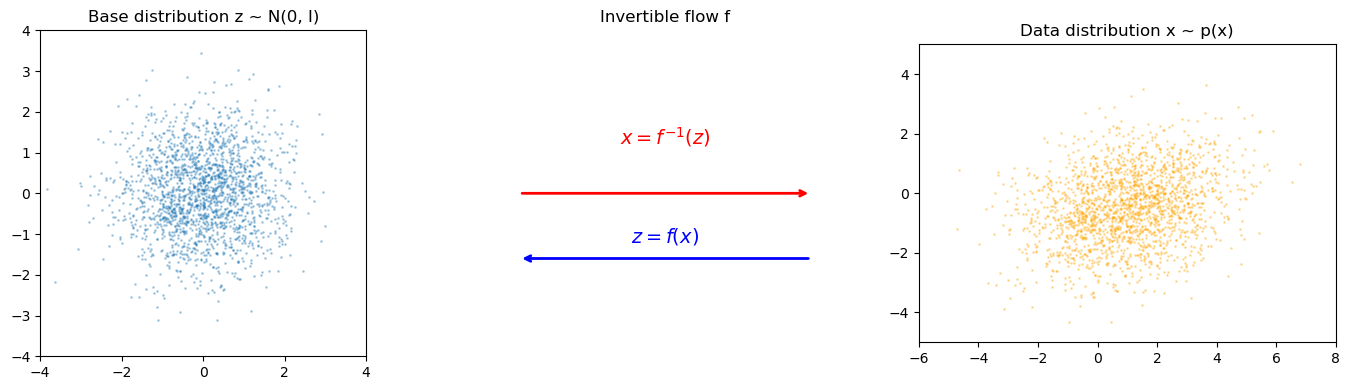

Log-det of Jacobian: 0.7129
This scalar corrects the density for the volume change under transformation.


In [2]:
# Visualize the core idea: a simple 2D flow transforming a Gaussian into a complex distribution
# (This is conceptual — Glow operates on images, but the principle is the same)

z = torch.randn(2000, 2)  # Base distribution: standard Gaussian

# A simple invertible transformation (for illustration)
W = torch.tensor([[1.5, 0.8], [-0.3, 1.2]])  # invertible matrix
x = z @ W.T + torch.tensor([1.0, -0.5])       # affine transform

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].scatter(z[:, 0], z[:, 1], s=1, alpha=0.3)
axes[0].set_title('Base distribution z ~ N(0, I)')
axes[0].set_xlim(-4, 4); axes[0].set_ylim(-4, 4)
axes[0].set_aspect('equal')

axes[1].annotate('', xy=(0.85, 0.5), xytext=(0.15, 0.5),
                 xycoords='axes fraction',
                 arrowprops=dict(arrowstyle='->', lw=2, color='red'))
axes[1].text(0.5, 0.65, r'$x = f^{-1}(z)$', transform=axes[1].transAxes,
             ha='center', fontsize=14, color='red')
axes[1].text(0.5, 0.35, r'$z = f(x)$', transform=axes[1].transAxes,
             ha='center', fontsize=14, color='blue')
axes[1].annotate('', xy=(0.15, 0.3), xytext=(0.85, 0.3),
                 xycoords='axes fraction',
                 arrowprops=dict(arrowstyle='->', lw=2, color='blue'))
axes[1].set_title('Invertible flow f')
axes[1].axis('off')

axes[2].scatter(x[:, 0], x[:, 1], s=1, alpha=0.3, color='orange')
axes[2].set_title('Data distribution x ~ p(x)')
axes[2].set_xlim(-6, 8); axes[2].set_ylim(-5, 5)
axes[2].set_aspect('equal')

plt.tight_layout()
plt.show()

print(f"Log-det of Jacobian: {torch.log(torch.abs(torch.det(W))).item():.4f}")
print("This scalar corrects the density for the volume change under transformation.")

---
## 2. Preprocessing: Dequantization <a id='2-preprocessing'></a>

Digital images have **discrete** pixel values in $\{0, 1, \ldots, 255\}$, but normalizing flows model **continuous** densities. Naively fitting a continuous model to discrete data causes the model to place all probability mass on the 256 discrete values, leading to degenerate solutions.

**Dequantization** (Uria et al., 2013) adds uniform noise to make the data continuous:

$$\tilde{x} = \frac{x + u}{256} - 0.5, \quad u \sim \text{Uniform}(0, 1)$$

This maps each integer pixel to a continuous interval of width $1/256$ and centers the data around 0.

To properly account for this in the log-likelihood, we subtract a correction term:

$$\log p_\text{discrete}(x) \geq \log p_\text{model}(\tilde{x}) - D \cdot \log(256)$$

where $D = C \times H \times W$ is the total number of sub-pixels.

In [3]:
# Demonstrate dequantization on a fake "image" batch
# Suppose pixel values in [0, 255] mapped to [0, 1] by ToTensor()

x_discrete = torch.randint(0, 256, (4, 3, 8, 8)).float() / 255.0  # simulated [0, 1] image

# Dequantization: add uniform noise, rescale to [-0.5, 0.5]
x_dequant = (x_discrete * 255 + torch.rand_like(x_discrete)) / 256.0 - 0.5

print(f"Discrete pixel range:      [{x_discrete.min():.3f}, {x_discrete.max():.3f}]")
print(f"Dequantized range:         [{x_dequant.min():.3f}, {x_dequant.max():.3f}]")
print(f"Dequantization correction: -D * log(256) = {-np.log(256) * 3 * 8 * 8:.1f}")
print(f"(for a 3x8x8 image with D={3*8*8} sub-pixels)")

Discrete pixel range:      [0.000, 1.000]
Dequantized range:         [-0.499, 0.499]
Dequantization correction: -D * log(256) = -1064.7
(for a 3x8x8 image with D=192 sub-pixels)


---
## 3. Step of Flow: The Three Components <a id='3-step-of-flow'></a>

Each "step of flow" in Glow (Table 1 in the paper) consists of three sub-layers applied in sequence:

| Step | Layer | Purpose |
|------|-------|---------|
| 1 | **Activation Normalization (ActNorm)** | Per-channel affine transform (replaces batch norm) |
| 2 | **Invertible 1x1 Convolution** | Learned channel permutation (generalizes fixed shuffling) |
| 3 | **Affine Coupling Layer** | Expressive nonlinear transform (the "workhorse") |

All three are invertible with tractable log-determinants.

---

### 3a. Activation Normalization (ActNorm)

**Problem:** Batch Normalization depends on batch statistics and doesn't work well with very small batch sizes (as needed for large images).

**Solution:** ActNorm is a per-channel affine transformation with **data-dependent initialization**:

$$y = s \odot (x + b)$$

where $s$ and $b$ are per-channel learnable parameters (shape: $1 \times C \times 1 \times 1$).

**Initialization:** On the first mini-batch, $b$ and $s$ are set so that the output has zero mean and unit variance per channel:
$$b \leftarrow -\text{mean}(x), \quad s \leftarrow 1 / \text{std}(x)$$

After initialization, $s$ and $b$ are treated as regular trainable parameters.

**Log-determinant:** Since $s$ acts independently on each channel at every spatial location:

$$\log |\det J| = H \cdot W \cdot \sum_{c=1}^{C} \log |s_c|$$

**Implementation detail:** For numerical stability, we store $\log s / \alpha$ and use $\log s \cdot \alpha$ at runtime, where $\alpha = 3$ (the `logscale_factor`).

In [4]:
from normalizing_flows.modules import ActNorm

# Create an ActNorm layer for 12 channels
actnorm = ActNorm(num_channels=12)
print(f"Initialized: {actnorm.initialized.item() == 1.0}")

# First forward pass triggers data-dependent initialization
x = torch.randn(8, 12, 16, 16) * 3.0 + 2.0  # mean ~2, std ~3
y, log_det = actnorm(x)

print(f"\nBefore ActNorm:  mean={x.mean(dim=[0,2,3]).mean():.3f}, std={x.std(dim=[0,2,3]).mean():.3f}")
print(f"After ActNorm:   mean={y.mean(dim=[0,2,3]).mean():.4f}, std={y.std(dim=[0,2,3]).mean():.4f}")
print(f"Initialized: {actnorm.initialized.item() == 1.0}")
print(f"\nLog-determinant: {log_det.item():.4f}")
print(f"  = H*W * sum(log|s|) = {16*16} * {(actnorm.log_scale * actnorm.logscale_factor).sum().item():.4f}")

# Verify invertibility
x_recon = actnorm.inverse(y)
print(f"\nInverse error: {(x - x_recon).abs().max().item():.2e}")

Initialized: False

Before ActNorm:  mean=2.014, std=3.012
After ActNorm:   mean=-0.0000, std=1.0002
Initialized: True

Log-determinant: -3386.2710
  = H*W * sum(log|s|) = 256 * -13.2276

Inverse error: 1.91e-06


### 3b. Invertible 1x1 Convolution

**Motivation:** Coupling layers (Step 3) only transform *half* the channels, conditioned on the other half. To ensure all channels interact, we need to permute them between coupling layers.

Prior work (RealNVP) used fixed permutations (reverse ordering or random shuffles). Glow generalizes this to a **learned** permutation via an invertible 1x1 convolution.

A 1x1 convolution with weight matrix $\mathbf{W} \in \mathbb{R}^{C \times C}$ acts independently on each spatial position:

$$y_{:,h,w} = \mathbf{W} \cdot x_{:,h,w}$$

**Log-determinant:** Since $\mathbf{W}$ is applied at each of $H \times W$ spatial positions:

$$\log |\det J| = H \cdot W \cdot \log |\det \mathbf{W}|$$

**LU Decomposition (Section 3.2 of paper):** Computing $\det \mathbf{W}$ naively costs $O(C^3)$. Glow uses the LU decomposition:

$$\mathbf{W} = \mathbf{P} \mathbf{L} \mathbf{U}$$

where:
- $\mathbf{P}$: permutation matrix (fixed after initialization)
- $\mathbf{L}$: lower triangular with ones on diagonal (learnable, below-diagonal entries)
- $\mathbf{U}$: upper triangular (learnable, above-diagonal entries + diagonal)

The determinant simplifies to the product of diagonal entries of $\mathbf{U}$:

$$\log |\det \mathbf{W}| = \sum_{c=1}^{C} \log |U_{cc}| = \sum_{c=1}^{C} \log |s_c|$$

This is $O(C)$ — a massive speedup!

**Initialization:** Start from a random orthogonal matrix (via QR decomposition), then decompose it into P, L, U.

Weight matrix W shape: torch.Size([12, 12])
det(W) = -1.0000
log|det(W)| = 0.0000
sum(log_s)  = 0.0000  (should match above)


/tmp/ipykernel_187318/3510373948.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


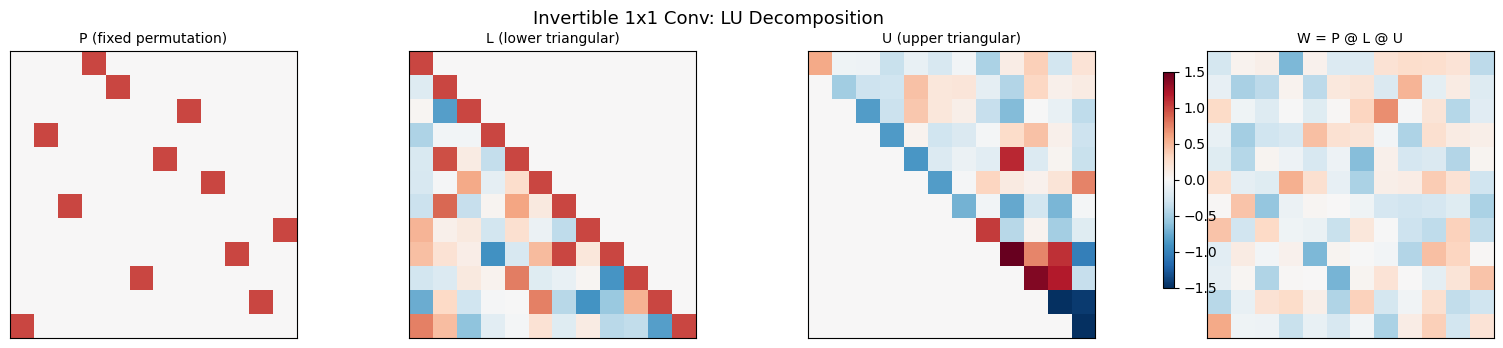


Log-det: 0.0000 = H*W * sum(log_s) = 64 * 0.0000
Inverse error: 7.15e-07


In [5]:
from normalizing_flows.modules import Invertible1x1Conv

C = 12
inv_conv = Invertible1x1Conv(C)

# Show the LU structure
W = inv_conv._get_weight()
print(f"Weight matrix W shape: {W.shape}")
print(f"det(W) = {torch.det(W).item():.4f}")
print(f"log|det(W)| = {torch.log(torch.abs(torch.det(W))).item():.4f}")
print(f"sum(log_s)  = {inv_conv.log_s.sum().item():.4f}  (should match above)")

# Visualize the weight matrix
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, (mat, title) in zip(axes, [
    (inv_conv.p, 'P (fixed permutation)'),
    (inv_conv.l * inv_conv.l_mask + inv_conv.eye, 'L (lower triangular)'),
    (inv_conv.u * inv_conv.u_mask + torch.diag(inv_conv.sign_s * torch.exp(inv_conv.log_s)),
     'U (upper triangular)'),
    (W, 'W = P @ L @ U'),
]):
    im = ax.imshow(mat.detach().numpy(), cmap='RdBu_r', vmin=-1.5, vmax=1.5)
    ax.set_title(title, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
plt.colorbar(im, ax=axes, shrink=0.8)
plt.suptitle('Invertible 1x1 Conv: LU Decomposition', fontsize=13)
plt.tight_layout()
plt.show()

# Verify invertibility
x = torch.randn(2, C, 8, 8)
y, log_det = inv_conv(x)
x_recon = inv_conv.inverse(y)
print(f"\nLog-det: {log_det.item():.4f} = H*W * sum(log_s) = {8*8} * {inv_conv.log_s.sum().item():.4f}")
print(f"Inverse error: {(x - x_recon).abs().max().item():.2e}")

### 3c. Affine Coupling Layer

The affine coupling layer (Dinh et al., 2016) is the only component that introduces **nonlinear** expressiveness. The key insight: if we only transform *half* the channels, the Jacobian becomes triangular and its determinant is trivial to compute.

**Split** the input channels into two halves: $\mathbf{x} = [\mathbf{x}_1, \mathbf{x}_2]$

**Forward:**
$$\mathbf{y}_1 = \mathbf{x}_1$$
$$\mathbf{y}_2 = (\mathbf{x}_2 + \mathbf{t}(\mathbf{x}_1)) \odot \mathbf{s}(\mathbf{x}_1)$$

where $\mathbf{s}$ and $\mathbf{t}$ are arbitrary neural networks (don't need to be invertible!). In Glow, $\mathbf{s}(\mathbf{x}_1) = \sigma(\text{NN}(\mathbf{x}_1) + 2)$ where $\sigma$ is the sigmoid function.

**Inverse** (trivially computed):
$$\mathbf{x}_1 = \mathbf{y}_1$$
$$\mathbf{x}_2 = \mathbf{y}_2 / \mathbf{s}(\mathbf{y}_1) - \mathbf{t}(\mathbf{y}_1)$$

**Log-determinant:** The Jacobian is lower-triangular with $\mathbf{s}$ on the diagonal:

$$\log |\det J| = \sum_{c, h, w} \log |s_{c,h,w}|$$

**The coupling network NN** is a 3-layer CNN:
1. Conv2d(3x3) → ActNorm → ReLU
2. Conv2d(1x1) → ActNorm → ReLU  
3. Conv2d(3x3, zero-initialized) × learnable log-scale

**Zero initialization** of the last layer is critical: it means the coupling layer starts as the identity function, making training stable from the start.

In [6]:
from normalizing_flows.modules import AffineCouplingLayer

C = 12
coupling = AffineCouplingLayer(num_channels=C, hidden_channels=64)

x = torch.randn(2, C, 8, 8)
y, log_det = coupling(x)

# The last conv is zero-init, but the internal actnorms perform data-dependent
# initialization on the first pass, which produces small nonzero outputs.
# The sigmoid scale is centered at sigmoid(0+2) ≈ 0.88, making the transform near-identity.
print("=== Near-Identity at Initialization ===")
print(f"sigmoid(2) = {torch.sigmoid(torch.tensor(2.0)).item():.4f}  (scale centered here)")
print(f"Max |y - x| at init: {(y - x).abs().max().item():.4f}")
print(f"Log-det at init:     {log_det.mean().item():.4f}")

# Verify invertibility
x_recon = coupling.inverse(y)
print(f"\nInverse error: {(x - x_recon).abs().max().item():.2e}")

# Verify: first half passes through unchanged, second half is transformed
print(f"\n=== Channel split ===")
half = C // 2
print(f"x1 (channels 0-{half-1}): unchanged    →  max |y1 - x1| = {(y[:, :half] - x[:, :half]).abs().max().item():.2e}")
print(f"x2 (channels {half}-{C-1}): transformed  →  max |y2 - x2| = {(y[:, half:] - x[:, half:]).abs().max().item():.4f}")

=== Near-Identity at Initialization ===
sigmoid(2) = 0.8808  (scale centered here)
Max |y - x| at init: 0.3952
Log-det at init:     -48.7404

Inverse error: 2.38e-07

=== Channel split ===
x1 (channels 0-5): unchanged    →  max |y1 - x1| = 0.00e+00
x2 (channels 6-11): transformed  →  max |y2 - x2| = 0.3952


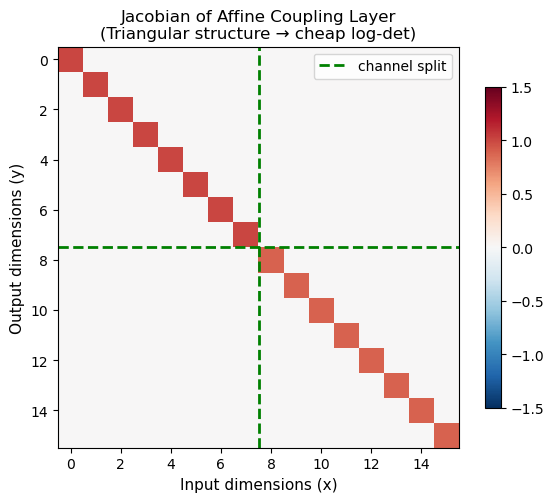

Top-left block (dy1/dx1): Identity (x1 passes through unchanged)
Top-right block (dy1/dx2): Zero (y1 doesn't depend on x2)
Bottom-left block (dy2/dx1): Dense (x2's transform depends on x1 via NN)
Bottom-right block (dy2/dx2): Diagonal (the scale s, applied element-wise)

log|det J| = sum(log diagonal) = sum(log s)


In [7]:
# Visualize how the coupling layer's Jacobian is triangular
# For a small example: 4 channels, 2x2 spatial

small_coupling = AffineCouplingLayer(num_channels=4, hidden_channels=32)

# Compute the full Jacobian numerically
x_small = torch.randn(1, 4, 2, 2, requires_grad=True)
y_small, _ = small_coupling(x_small)

D = 4 * 2 * 2  # total dimensions
jacobian = torch.zeros(D, D)
y_flat = y_small.view(-1)
for i in range(D):
    if x_small.grad is not None:
        x_small.grad.zero_()
    y_flat[i].backward(retain_graph=True)
    jacobian[i] = x_small.grad.view(-1)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(jacobian.detach().numpy(), cmap='RdBu_r', vmin=-1.5, vmax=1.5)
ax.set_xlabel('Input dimensions (x)', fontsize=11)
ax.set_ylabel('Output dimensions (y)', fontsize=11)
ax.set_title('Jacobian of Affine Coupling Layer\n(Triangular structure → cheap log-det)', fontsize=12)
ax.axhline(y=D//2 - 0.5, color='green', linewidth=2, linestyle='--', label='channel split')
ax.axvline(x=D//2 - 0.5, color='green', linewidth=2, linestyle='--')
ax.legend(fontsize=10)
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

print("Top-left block (dy1/dx1): Identity (x1 passes through unchanged)")
print("Top-right block (dy1/dx2): Zero (y1 doesn't depend on x2)")
print("Bottom-left block (dy2/dx1): Dense (x2's transform depends on x1 via NN)")
print("Bottom-right block (dy2/dx2): Diagonal (the scale s, applied element-wise)")
print(f"\nlog|det J| = sum(log diagonal) = sum(log s)")

---
## 4. Multi-Scale Architecture <a id='4-multi-scale'></a>

Glow uses a **multi-scale architecture** (from RealNVP) that progressively factors out latent variables at different resolutions. This:
1. Reduces computational cost (by halving the spatial tensor at each level)
2. Captures features at multiple spatial scales
3. Distributes the latent representation across resolutions

The architecture at each **level** $\ell$:

```
Input: h (B, C, H, W)
  │
  ▼ Squeeze: (B, C, H, W) → (B, 4C, H/2, W/2)
  │
  ▼ K × Flow Steps (ActNorm → Inv1x1Conv → Coupling)
  │
  ▼ Split: (B, 4C, H/2, W/2) → keep (B, 2C, H/2, W/2) + factor out z_ℓ (B, 2C, H/2, W/2)
  │
  ▼ Continue with (B, 2C, H/2, W/2) to next level
```

At the **last level**, there is no split — the entire tensor becomes the final latent $\mathbf{z}_L$.

### Dimension trace for 64x64 RGB images with L=3 levels:

| Level | After Squeeze | After K Steps | After Split | Factor out |
|-------|--------------|---------------|-------------|------------|
| 1 | (12, 32, 32) | (12, 32, 32) | (6, 32, 32) | z₁: (6, 32, 32) |
| 2 | (24, 16, 16) | (24, 16, 16) | (12, 16, 16) | z₂: (12, 16, 16) |
| 3 | (48, 8, 8) | (48, 8, 8) | — (no split) | z₃: (48, 8, 8) |

Total latent dimensions: $6 \times 32^2 + 12 \times 16^2 + 48 \times 8^2 = 6144 + 3072 + 3072 = 12288 = 3 \times 64^2$ ✓

### 4a. Squeeze Operation

The squeeze operation reshapes spatial dimensions into channel dimensions using a **checkerboard pattern**:

$(B, C, H, W) \to (B, 4C, H/2, W/2)$

It groups every 2x2 spatial block into 4 channel slices:

```
Spatial 4x4, 1 channel:          After squeeze: 2x2, 4 channels

 a b | c d                         Channel 0: a c    Channel 1: b d
 e f | g h          ──────►                   i k               j l
 ----+----
 i j | k l                         Channel 2: e g    Channel 3: f h
 m n | o p                                    m o               n p
```

This is a **volume-preserving** reshape (determinant = 1, so no log-det contribution).

In [8]:
from normalizing_flows.modules import squeeze, unsqueeze

# Demonstrate squeeze on a simple tensor
x = torch.arange(48).float().view(1, 3, 4, 4)  # (1, 3, 4, 4)
z = squeeze(x)                                    # (1, 12, 2, 2)
x_recon = unsqueeze(z)                            # (1, 3, 4, 4)

print(f"Input shape:     {x.shape}  →  {3*4*4} = {x.numel()} elements")
print(f"Squeezed shape:  {z.shape}  →  {12*2*2} = {z.numel()} elements")
print(f"Roundtrip error: {(x - x_recon).abs().max().item():.0e}")

# Visualize the spatial rearrangement for channel 0
print(f"\nOriginal channel 0 (4x4):")
print(x[0, 0].int().numpy())
print(f"\nAfter squeeze — now 4 channels of 2x2:")
for c in range(4):
    print(f"  Channel {c}: {z[0, c].int().numpy().tolist()}")

Input shape:     torch.Size([1, 3, 4, 4])  →  48 = 48 elements
Squeezed shape:  torch.Size([1, 12, 2, 2])  →  48 = 48 elements
Roundtrip error: 0e+00

Original channel 0 (4x4):
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]]

After squeeze — now 4 channels of 2x2:
  Channel 0: [[0, 2], [8, 10]]
  Channel 1: [[1, 3], [9, 11]]
  Channel 2: [[4, 6], [12, 14]]
  Channel 3: [[5, 7], [13, 15]]


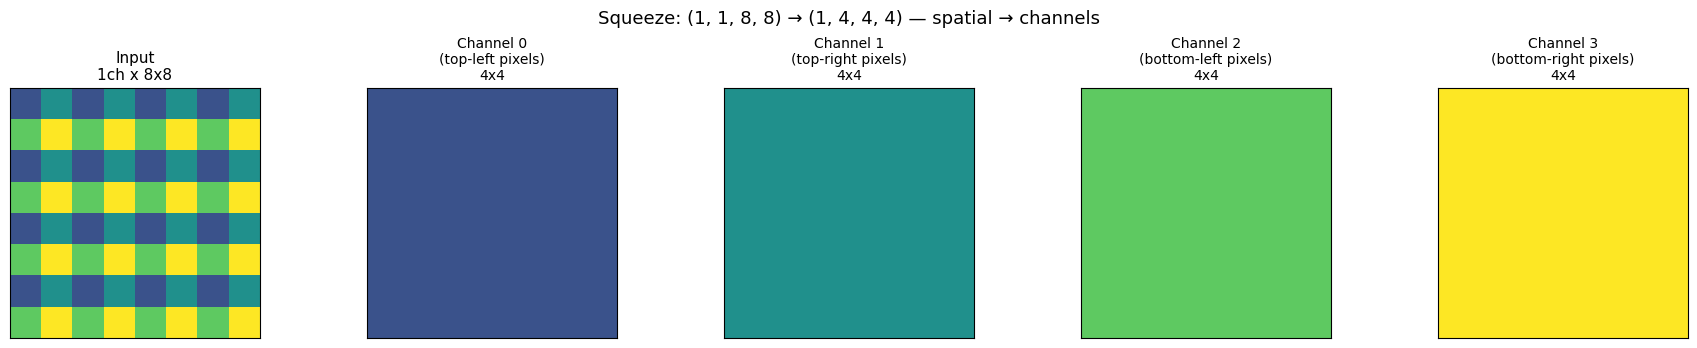

In [9]:
# Visual demonstration with an actual image-like tensor
# Create a checkerboard pattern to show how squeeze rearranges pixels

H, W = 8, 8
img = torch.zeros(1, 1, H, W)
# Color the 2x2 sub-blocks with different values to show grouping
for i in range(0, H, 2):
    for j in range(0, W, 2):
        img[0, 0, i, j] = 1      # top-left of each 2x2
        img[0, 0, i, j+1] = 2    # top-right
        img[0, 0, i+1, j] = 3    # bottom-left
        img[0, 0, i+1, j+1] = 4  # bottom-right

squeezed = squeeze(img)  # (1, 4, 4, 4)

fig, axes = plt.subplots(1, 5, figsize=(18, 3.5))
axes[0].imshow(img[0, 0], cmap='viridis', vmin=0, vmax=4)
axes[0].set_title(f'Input\n{img.shape[1]}ch x {H}x{W}', fontsize=11)
for c in range(4):
    axes[c+1].imshow(squeezed[0, c], cmap='viridis', vmin=0, vmax=4)
    pos = ['top-left', 'top-right', 'bottom-left', 'bottom-right'][c]
    axes[c+1].set_title(f'Channel {c}\n({pos} pixels)\n{squeezed.shape[2]}x{squeezed.shape[3]}', fontsize=10)
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('Squeeze: (1, 1, 8, 8) → (1, 4, 4, 4) — spatial → channels', fontsize=13)
plt.tight_layout()
plt.show()

### 4b. Split Operation & Learned Prior

After K flow steps at each level (except the last), the channels are split in half:
- **First half** continues to the next level
- **Second half** is "factored out" as a latent variable $\mathbf{z}_\ell$

The factored-out variables use a **learned Gaussian prior** conditioned on the kept channels:

$$p(\mathbf{z}_{\text{out}} \mid \mathbf{h}_{\text{kept}}) = \mathcal{N}\big(\boldsymbol{\mu}(\mathbf{h}_{\text{kept}}),\; \boldsymbol{\sigma}^2(\mathbf{h}_{\text{kept}})\big)$$

where $\boldsymbol{\mu}$ and $\log \boldsymbol{\sigma}$ are predicted by a zero-initialized convolution from $\mathbf{h}_{\text{kept}}$.

This is more expressive than a fixed $\mathcal{N}(\mathbf{0}, \mathbf{I})$ prior because it lets the model capture correlations between the kept and factored-out channels.

**At the final level**, there's no split — the full tensor uses a standard Gaussian prior $\mathcal{N}(\mathbf{0}, \mathbf{I})$.

**Log-likelihood contribution:**
$$\log p(\mathbf{z}_{\text{out}} \mid \mathbf{h}) = -\frac{1}{2} \sum \left[ \log 2\pi + 2\log\sigma + \frac{(z - \mu)^2}{\sigma^2} \right]$$

In [10]:
from normalizing_flows.modules import SplitPrior

# The split prior predicts mean and log-std for the factored-out channels
split_prior = SplitPrior(num_channels=6)  # 6 kept channels → predicts for 6 factored-out

h_kept = torch.randn(2, 6, 16, 16)  # the "kept" channels
z_out  = torch.randn(2, 6, 16, 16)  # the "factored out" channels

# Predict prior parameters
mean, log_std = split_prior(h_kept)
print(f"Predicted mean shape:    {mean.shape}")
print(f"Predicted log_std shape: {log_std.shape}")

# At initialization (zero-init conv), the prior is approximately N(0, 1)
print(f"\nInitial mean ≈ 0:    {mean.abs().max().item():.6f}")
print(f"Initial log_std ≈ 0: {log_std.abs().max().item():.6f}")

# Compute log probability under the learned prior
log_p = split_prior.log_prob(h_kept, z_out)
print(f"\nLog p(z_out | h_kept): {log_p}")

# Sample from the learned prior
z_sampled = split_prior.sample(h_kept, temperature=0.7)
print(f"Sampled z shape: {z_sampled.shape}")

Predicted mean shape:    torch.Size([2, 6, 16, 16])
Predicted log_std shape: torch.Size([2, 6, 16, 16])

Initial mean ≈ 0:    0.000000
Initial log_std ≈ 0: 0.000000

Log p(z_out | h_kept): tensor([-2194.0535, -2158.8872], grad_fn=<MulBackward0>)
Sampled z shape: torch.Size([2, 6, 16, 16])


---
## 5. Putting It All Together: The Full Glow Model <a id='5-full-model'></a>

The complete Glow architecture stacks $L$ levels, each containing $K$ flow steps:

```
x (B, 3, 64, 64)
│
├─ Level 1: Squeeze → [ActNorm → Inv1x1Conv → Coupling] × K → Split
│  ├─ z₁ factored out: (B, 6, 32, 32)     ← learned prior p(z₁ | h₁)
│  └─ h₁ continues:    (B, 6, 32, 32)
│
├─ Level 2: Squeeze → [ActNorm → Inv1x1Conv → Coupling] × K → Split
│  ├─ z₂ factored out: (B, 12, 16, 16)    ← learned prior p(z₂ | h₂)
│  └─ h₂ continues:    (B, 12, 16, 16)
│
└─ Level 3: Squeeze → [ActNorm → Inv1x1Conv → Coupling] × K → (no split)
   └─ z₃ final latent: (B, 48, 8, 8)      ← standard prior N(0, I)
```

**Full log-likelihood:**

$$\log p(\mathbf{x}) = \underbrace{\log p(\mathbf{z}_L)}_{\text{final prior}} + \underbrace{\sum_{\ell=1}^{L-1} \log p(\mathbf{z}_\ell \mid \mathbf{h}_\ell)}_{\text{learned split priors}} + \underbrace{\sum_{k=1}^{K \cdot L} \log |\det J_k|}_{\text{flow step log-dets}} \underbrace{- D \cdot \log(256)}_{\text{dequantization}}$$

In [11]:
from normalizing_flows.model import GlowModel

# Create a Glow model with the same config as our training script
model = GlowModel(
    in_channels=3,
    num_levels=3,     # L = 3 levels
    num_steps=8,      # K = 8 flow steps per level
    hidden_channels=256
)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")
print(f"\nArchitecture:")
print(f"  Levels: {model.num_levels}")
for i, level in enumerate(model.levels):
    n_steps = len(level.steps)
    has_split = level.split
    level_params = sum(p.numel() for p in level.parameters())
    print(f"  Level {i+1}: {n_steps} flow steps, split={has_split}, params={level_params:,}")

Total parameters: 3,987,288

Architecture:
  Levels: 3
  Level 1: 8 flow steps, split=True, params=871,832
  Level 2: 8 flow steps, split=True, params=1,212,968
  Level 3: 8 flow steps, split=False, params=1,902,488


In [12]:
# Trace the forward pass to see dimension changes at each stage

x = torch.randn(2, 3, 64, 64)
print(f"Input: {x.shape}")
print("=" * 60)

h = x
total_log_det = torch.zeros(2)
z_list = []

for i, level in enumerate(model.levels):
    from normalizing_flows.modules import squeeze as sq
    h_squeezed = sq(h)
    print(f"\nLevel {i+1}:")
    print(f"  Squeeze: {h.shape} → {h_squeezed.shape}")
    
    h, z_out, log_det = level(h)
    total_log_det += log_det.detach()
    z_list.append(z_out)
    
    if level.split:
        print(f"  After {len(level.steps)} flow steps + Split:")
        print(f"    Factored out z_{i+1}: {z_out.shape}  (dim={z_out[0].numel()})")
        print(f"    Continues h:          {h.shape}  (dim={h[0].numel()})")
    else:
        print(f"  After {len(level.steps)} flow steps (no split):")
        print(f"    Final z_{i+1}:         {z_out.shape}  (dim={z_out[0].numel()})")
    print(f"  Log-det contribution:   {log_det.mean().item():.2f}")

print("\n" + "=" * 60)
total_latent_dim = sum(z[0].numel() for z in z_list)
print(f"Total latent dimensions: {total_latent_dim} = {3}×{64}×{64} = {3*64*64} ✓")
print(f"Total log-det: {total_log_det.mean().item():.2f}")

Input: torch.Size([2, 3, 64, 64])

Level 1:
  Squeeze: torch.Size([2, 3, 64, 64]) → torch.Size([2, 12, 32, 32])
  After 8 flow steps + Split:
    Factored out z_1: torch.Size([2, 6, 32, 32])  (dim=6144)
    Continues h:          torch.Size([2, 6, 32, 32])  (dim=6144)
  Log-det contribution:   -8738.20

Level 2:
  Squeeze: torch.Size([2, 6, 32, 32]) → torch.Size([2, 24, 16, 16])
  After 8 flow steps + Split:
    Factored out z_2: torch.Size([2, 12, 16, 16])  (dim=3072)
    Continues h:          torch.Size([2, 12, 16, 16])  (dim=3072)
  Log-det contribution:   -4399.43

Level 3:
  Squeeze: torch.Size([2, 12, 16, 16]) → torch.Size([2, 48, 8, 8])
  After 8 flow steps (no split):
    Final z_3:         torch.Size([2, 48, 8, 8])  (dim=3072)
  Log-det contribution:   -85.93

Total latent dimensions: 12288 = 3×64×64 = 12288 ✓
Total log-det: -13223.55


---
## 6. Training Objective: Bits Per Dimension <a id='6-training'></a>

Glow is trained by maximizing the log-likelihood, or equivalently minimizing the negative log-likelihood (NLL).

The loss per sample is:
$$\mathcal{L} = -\log p(\mathbf{x})$$

Results are reported in **bits per dimension (BPD)**, which normalizes by the number of sub-pixels and converts from nats to bits:

$$\text{BPD} = \frac{-\log p(\mathbf{x})}{D \cdot \log 2}$$

where $D = C \times H \times W$. Lower BPD means a better model. For reference:
- Uniform random: 8.0 BPD (8 bits per pixel)
- Glow on CelebA 256x256: ~1.03 BPD
- Glow on CIFAR-10: ~3.35 BPD

In [13]:
# Demonstrate the training objective calculation

x = torch.randn(4, 3, 64, 64)  # pretend this is preprocessed image data

# Forward pass: compute log p(x)
log_prob = model.log_prob(x)
print(f"Log p(x) per sample: {log_prob.detach().numpy()}")

# NLL loss (what we minimize)
loss = -log_prob.mean()
print(f"\nNLL loss: {loss.item():.2f}")

# Convert to bits per dimension
D = 3 * 64 * 64  # total sub-pixels
bpd = loss.item() / (D * np.log(2))
print(f"Bits per dimension: {bpd:.3f}")
print(f"  = {loss.item():.2f} / ({D} * {np.log(2):.4f})")

# The decomposition of log p(x)
z_list, log_det = model.forward(x)
z_final = z_list[-1]
log_pz = -0.5 * (z_final ** 2 + np.log(2 * np.pi)).sum(dim=[1, 2, 3])
log_dequant = -np.log(256.0) * D

print(f"\n--- Decomposition of log p(x) ---")
print(f"  log p(z_final):           {log_pz.mean().item():>12.2f}  (Gaussian prior)")
print(f"  sum log|det J| + split:   {log_det.mean().item():>12.2f}  (flow transforms + split priors)")
print(f"  -D*log(256):              {log_dequant:>12.2f}  (dequantization correction)")
print(f"  ─────────────────────────────────")
print(f"  log p(x):                 {(log_pz + log_det + log_dequant).mean().item():>12.2f}")

Log p(x) per sample: [-85863.79 -85889.93 -85793.92 -85869.92]

NLL loss: 85854.39
Bits per dimension: 10.080
  = 85854.39 / (12288 * 0.6931)

--- Decomposition of log p(x) ---
  log p(z_final):               -4449.88  (Gaussian prior)
  sum log|det J| + split:      -13265.38  (flow transforms + split priors)
  -D*log(256):                 -68139.14  (dequantization correction)
  ─────────────────────────────────
  log p(x):                    -85854.39


---
## 7. Sampling / Generation <a id='7-sampling'></a>

To **generate** new images, we run the flow in reverse:

1. Sample $\mathbf{z}_L \sim \mathcal{N}(\mathbf{0}, T^2 \mathbf{I})$ for the final level
2. Run the inverse of Level $L$: undo flow steps, then unsqueeze
3. For each intermediate level $\ell = L-1, \ldots, 1$:
   - Sample $\mathbf{z}_\ell$ from the **learned split prior** conditioned on the current $\mathbf{h}$
   - Concatenate: $[\mathbf{h}, \mathbf{z}_\ell]$
   - Run inverse of Level $\ell$: undo flow steps, then unsqueeze
4. The output is the generated image $\hat{\mathbf{x}}$

**Temperature $T$** controls the trade-off between sample quality and diversity:
- $T = 0$: deterministic (mean of prior), sharp but no diversity
- $T = 0.7$: common default, good quality
- $T = 1.0$: sampling from the true prior, maximum diversity

```
z₃ ~ N(0, T²I)          ← sample final latent
  │
  ▼ Level 3 inverse: [Coupling⁻¹ → Inv1x1Conv⁻¹ → ActNorm⁻¹] × K → Unsqueeze
  │
  ├─ z₂ ~ p(z₂ | h)     ← sample from learned split prior
  ▼ Level 2 inverse: concat → [steps]⁻¹ → Unsqueeze
  │
  ├─ z₁ ~ p(z₁ | h)     ← sample from learned split prior
  ▼ Level 1 inverse: concat → [steps]⁻¹ → Unsqueeze
  │
  ▼
  x̂ (generated image)
```

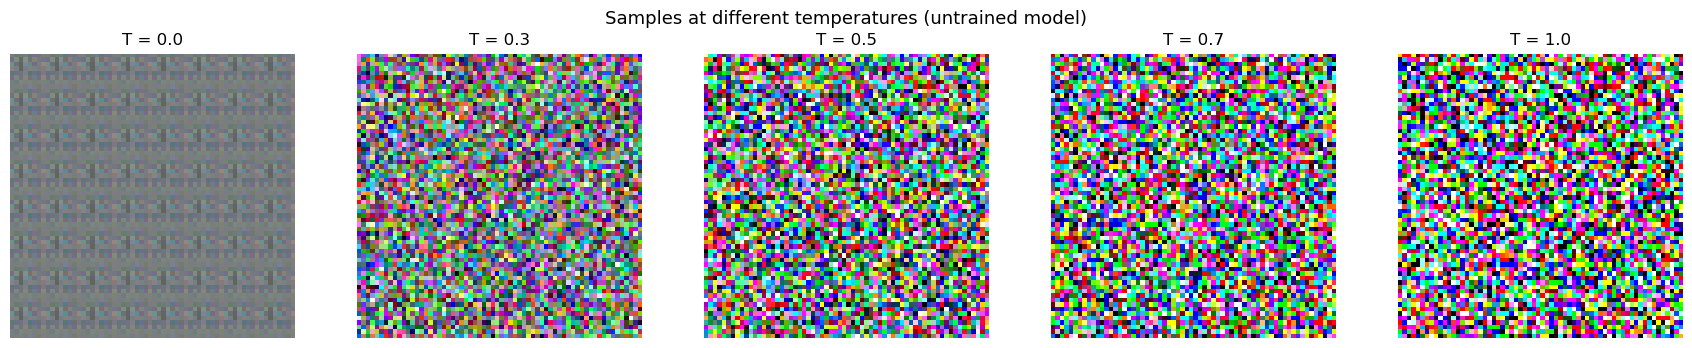

With an untrained model, these are noise. After training, T=0.7 typically gives the best visual quality.


In [14]:
# Demonstrate sampling at different temperatures
# (Using an untrained model, so outputs will be noise — but the mechanics are correct)

temperatures = [0.0, 0.3, 0.5, 0.7, 1.0]

fig, axes = plt.subplots(1, len(temperatures), figsize=(3.5 * len(temperatures), 3.5))

with torch.no_grad():
    for i, T in enumerate(temperatures):
        sample = model.sample(1, device='cpu', temperature=T)
        # Rescale from [-0.5, 0.5] to [0, 1]
        img = (sample[0] + 0.5).clamp(0, 1).permute(1, 2, 0).numpy()
        axes[i].imshow(img)
        axes[i].set_title(f'T = {T}', fontsize=12)
        axes[i].axis('off')

plt.suptitle('Samples at different temperatures (untrained model)', fontsize=13)
plt.tight_layout()
plt.show()
print("With an untrained model, these are noise. After training, T=0.7 typically gives the best visual quality.")

---
## 8. Numerical Verification: Roundtrip & Log-Det <a id='8-verification'></a>

A critical property of normalizing flows: the forward and inverse transformations must be **exact inverses**. Let's verify this numerically for our implementation.

We check two things:
1. **Roundtrip consistency**: $f^{-1}(f(\mathbf{x})) \approx \mathbf{x}$ (up to floating-point precision)
2. **Log-det correctness**: Compare our analytical log-det to the numerically computed one

In [15]:
# Test 1: Full model roundtrip
print("=== Roundtrip Test (Full Model) ===")
x = torch.randn(2, 3, 64, 64)
with torch.no_grad():
    z_list, log_det = model.forward(x)
    x_recon = model.inverse(z_list)
    err = (x - x_recon).abs().max().item()
    print(f"Max |x - f⁻¹(f(x))|: {err:.2e}")
    print(f"{'PASS' if err < 1e-4 else 'FAIL'}: Roundtrip error {'within' if err < 1e-4 else 'exceeds'} tolerance")

=== Roundtrip Test (Full Model) ===
Max |x - f⁻¹(f(x))|: 5.19e-06
PASS: Roundtrip error within tolerance


In [16]:
# Test 2: Per-component roundtrip verification
from normalizing_flows.modules import ActNorm, Invertible1x1Conv, AffineCouplingLayer

print("=== Per-Component Roundtrip ===")
C = 12
x = torch.randn(2, C, 8, 8)

components = [
    ("ActNorm", ActNorm(C)),
    ("Inv1x1Conv", Invertible1x1Conv(C)),
    ("AffineCoupling", AffineCouplingLayer(C, hidden_channels=64)),
]

for name, layer in components:
    with torch.no_grad():
        y, log_det = layer(x)
        x_recon = layer.inverse(y)
        err = (x - x_recon).abs().max().item()
        print(f"  {name:20s}  error: {err:.2e}  log_det: {log_det.mean().item():>10.4f}  {'✓' if err < 1e-5 else '✗'}")

=== Per-Component Roundtrip ===
  ActNorm               error: 2.38e-07  log_det:    18.1588  ✓
  Inv1x1Conv            error: 1.19e-06  log_det:     0.0000  ✓
  AffineCoupling        error: 2.38e-07  log_det:   -48.7404  ✓


In [17]:
# Test 3: Verify log-det of Inv1x1Conv against numerical computation
print("=== Log-Det Verification (Inv1x1Conv) ===")

C = 4  # small for numerical Jacobian
inv_conv = Invertible1x1Conv(C)
x = torch.randn(1, C, 2, 2, requires_grad=True)

# Analytical log-det from our implementation
y, log_det_analytical = inv_conv(x)

# Numerical log-det via full Jacobian
D = C * 2 * 2
jacobian = torch.zeros(D, D)
y_flat = y.view(-1)
for i in range(D):
    if x.grad is not None:
        x.grad.zero_()
    y_flat[i].backward(retain_graph=True)
    jacobian[i] = x.grad.view(-1)

log_det_numerical = torch.log(torch.abs(torch.det(jacobian)))

print(f"  Analytical log|det|: {log_det_analytical.item():.6f}")
print(f"  Numerical  log|det|: {log_det_numerical.item():.6f}")
print(f"  Difference:          {abs(log_det_analytical.item() - log_det_numerical.item()):.2e}")

=== Log-Det Verification (Inv1x1Conv) ===
  Analytical log|det|: -0.000000
  Numerical  log|det|: -0.000000
  Difference:          1.19e-07


In [18]:
# Test 4: Verify log-det of AffineCoupling against numerical Jacobian
print("=== Log-Det Verification (Affine Coupling) ===")

C = 4
coupling = AffineCouplingLayer(C, hidden_channels=32)
x = torch.randn(1, C, 2, 2, requires_grad=True)

y, log_det_analytical = coupling(x)

D = C * 2 * 2
jacobian = torch.zeros(D, D)
y_flat = y.view(-1)
for i in range(D):
    if x.grad is not None:
        x.grad.zero_()
    y_flat[i].backward(retain_graph=True)
    jacobian[i] = x.grad.view(-1)

log_det_numerical = torch.log(torch.abs(torch.det(jacobian)))

print(f"  Analytical log|det|: {log_det_analytical.item():.6f}")
print(f"  Numerical  log|det|: {log_det_numerical.item():.6f}")
print(f"  Difference:          {abs(log_det_analytical.item() - log_det_numerical.item()):.2e}")

=== Log-Det Verification (Affine Coupling) ===
  Analytical log|det|: -1.015425
  Numerical  log|det|: -1.015424
  Difference:          1.19e-07


---
## Summary

### Key Design Principles of Glow

| Design Choice | Why |
|---|---|
| **ActNorm** (not BatchNorm) | Works with batch size 1; data-dependent init for stable training |
| **Invertible 1x1 Conv** (not fixed permutation) | Learned channel mixing; generalizes reverse/shuffle; LU decomposition for O(C) log-det |
| **Affine coupling** (not additive) | More expressive (scale + shift vs. shift only) |
| **Zero-init last layer** | Flow starts as identity → stable optimization |
| **Multi-scale with split** | Reduces computation; captures multi-resolution features |
| **Learned split prior** | More expressive than fixed N(0,I); captures correlations across scales |
| **Sigmoid scale** σ(h+2) | Bounded, positive scale; centered near 1 for stability |

### Comparison with Prior Work

| | NICE (2014) | RealNVP (2016) | **Glow (2018)** |
|---|---|---|---|
| Coupling | Additive | Affine | Affine |
| Channel mixing | None | Fixed reverse | **Learned 1x1 conv** |
| Normalization | None | Batch Norm | **ActNorm** |
| Multi-scale | No | Yes | Yes |
| Split prior | N/A | Fixed N(0,I) | **Learned** |

### References
- Kingma & Dhariwal, "Glow: Generative Flow with Invertible 1x1 Convolutions", NeurIPS 2018
- Dinh et al., "Density estimation using Real-valued Non-Volume Preserving (RealNVP) transformations", ICLR 2017
- Dinh et al., "NICE: Non-linear Independent Components Estimation", ICLR Workshop 2015